# Código ejemplo de SPH
## Shear driven cavity (Cavidad accionada por cizalla)

Un fluido se mueve como un flujo incompresible dentro de un cuadrado cerrado, el movimiento es causado a una velocidad constante $V_{top}$ en el lado de arriba del cuadrado mientras en los otros tres lados permanece estacionario. El fluido llegará a una estado estable formando un patrón de circulación.

Para este caso el lado del cuadrado mide $l=10^{-3}\:m$, $\rho=10^3\:kg/m^3$, la viscosidad cinemática $\nu=10^{-6}\:m^2/s$ y $V_{top}=10^{-3}\:m/s$.

In [ ]:
# Liberias adicionales

from numpy import *
from matplotlib.pyplot import *

# Condiciones iniciales 

- Se usaran 1600 partículas para la simulacion ubicadas inicialmente en un arreglo tipo malla de $40\times40$ partículas.
- Como el fluido está inicialmente en reposo, el campo de velocidades se inicializa a cero.
- Se usará una variable para controlar el tipo de partícula, cuyo valor será 1 para partículas reales y -1 para partículas virtuales.
- Se usarán 320 partículas virtuales tipo I formando los bordes del cuadrado con 81 partículas en cada borde. La  velocidad de las partículas virtuales en el borde superior es igual a $V_{top}$ y del resto es igual a $0$.


- Como la masa por partícula es $m=\rho*dxdy$

dx = 2.5e-05 - dy = 2.5e-05
40 1.25e-05 0.0009875
1600 1.25e-05 0.0009875
81
79
81
79
320 particulas virtuales



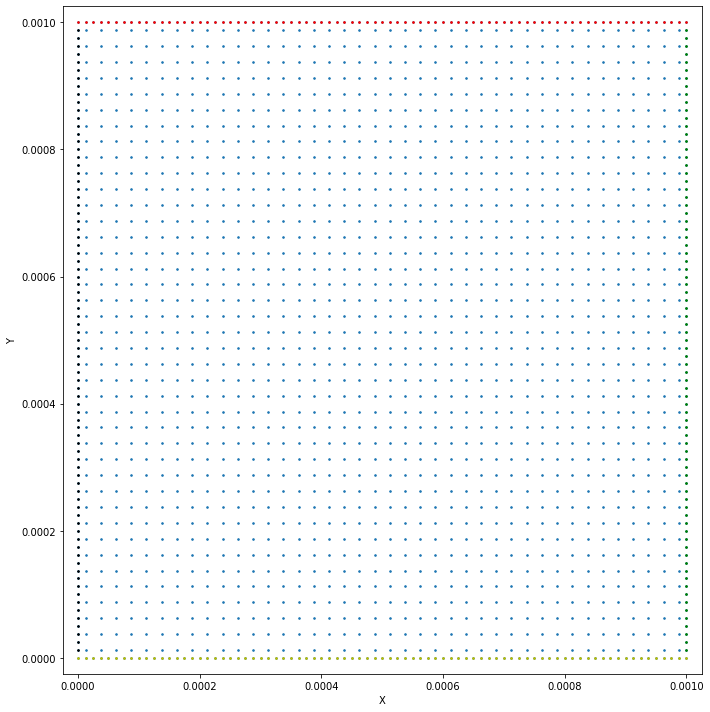

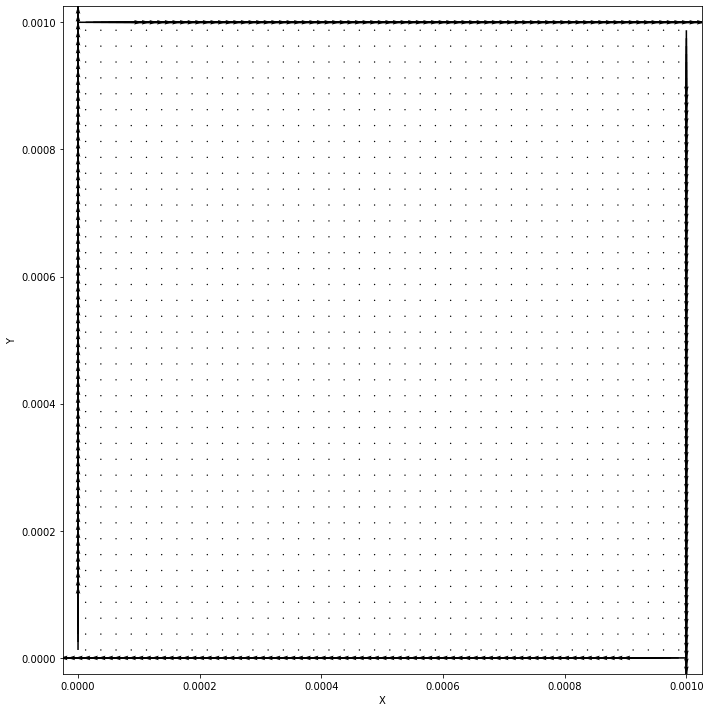

In [ ]:
# posicion inicial de las particulas reales

nx = 40     # numero de puntos en x
ny = 40     # numero de puntos en y
nTotal = nx*ny # numero de particulas total
Lx = 0.001 # longitud total en x
Ly = 0.001  # longitud total en y

dx = Lx/(nx)
dy = Ly/(ny)

print("dx =",dx,"- dy =",dy)

X_ini = 0.0 # posicion inicial en x para el grid
Y_ini = 0.0 # posicion inicial en y para el grid

px = arange(X_ini + dx/2.0, X_ini + nx*dx, dx, dtype=float)
py = arange(Y_ini + dy/2.0, Y_ini + ny*dy, dy, dtype=float)
print(len(px),px[0],px[-1])

#for i in range(1,len(px)):
    #print("%.10f  %.10f"%(px[i]-px[i-1],py[i]-py[i-1]))


x = []  # arreglo con las posiciones en x
y = []  # arreglo con las posiciones en y 

for i in range(nx):
    for j in range(ny):
        #print(i,j, px[i],py[j])
        x.append(px[i])
        y.append(py[j])

print(len(x),x[0],x[-1])

# velocidad

vx = []  # arreglo con las velocidades en x
vy = []  # arreglo con las velocidades en y 

for i in range(nx):
    for j in range(ny):
        vx.append(0.0)
        vy.append(0.0)

# densidad, masa, presión, energía interna, 
# longitud de suavizado, velocidad del sonido, tipo de partícula 

rho = []
m = []
p = []
u = []
h = []
c = []
tipo = []

for i in range(nTotal):
    rho.append(1000)
    m.append(dx*dy*rho[i])
    p.append(0.0)
    u.append(357.1)
    h.append(dx)
    c.append(0.0)
    tipo.append(1)

# partículas virtuales tipo I para al frontera
V_top = 1e-2
#V_top = 100.0
npVirt = 320
npV = int(320/4)

# particulas de la frontera superior
X_ini = 0.0
px = arange(X_ini, X_ini + (npV*dx/2.0) + (dx/2.0), dx/2.0, dtype=float)

#for i in range(1,len(px)):
    #print("%.10f"%(px[i]-px[i-1]))

xVIup = []
yVIup = []
for i in range(len(px)):
    x.append(px[i])
    y.append(Ly)
    vx.append(V_top)
    vy.append(0.0)
    xVIup.append(px[i])
    yVIup.append(Ly)
    tipo.append(-1)
print(len(xVIup))
    
#particulas de la frontera derecha
Y_ini = 0.0
py = arange(Y_ini + dy/2.0, Y_ini + npV*dy/2.0, dy/2.0, dtype=float)

xVIrg = []
yVIrg = []
for i in range(len(py)):
    x.append(Lx)
    y.append(py[i])
    vx.append(0.0)
    vy.append(-V_top)
    xVIrg.append(Lx)
    yVIrg.append(py[i])
    tipo.append(-1)

print(len(xVIrg))

#particulas de la frontera inferior
X_ini = 0.0
px = arange(X_ini, X_ini + npV*dx/2.0 + dx/2.0, dx/2.0, dtype=float)

xVIbt = []
yVIbt = []
for i in range(len(px)):
    x.append(px[i])
    y.append(0.0)
    vx.append(-V_top)
    vy.append(0.0)
    xVIbt.append(px[i])
    yVIbt.append(0.0)
    tipo.append(-1)

print(len(xVIbt))

#particulas de la frontera izquierda
Y_ini = 0.0
py = arange(Y_ini + dy/2.0, Y_ini + npV*dy/2.0, dy/2.0, dtype=float)

xVIlf = []
yVIlf = []
for i in range(len(py)):
    x.append(0.0)
    y.append(py[i])
    vx.append(0.0)
    vy.append(V_top)
    xVIlf.append(0.0)
    yVIlf.append(py[i])
    tipo.append(-1)

print(len(xVIlf))

print(len(xVIup)+len(xVIrg)+len(xVIbt)+len(xVIlf),"particulas virtuales\n")

# densidad, masa, presión, energía interna, 
# longitud de suavizado para particulas virtuales

for i in range(npVirt):
    rho.append(1000)
    m.append(dx*dy*rho[i])
    p.append(0.0)
    u.append(357.1)
    h.append(dx)
    c.append(0.0)

# grafica posiciones

figure(figsize=(10,10))
scatter(x,y,s=10,marker='.')
scatter(xVIup,yVIup,s=10,marker='.',c='r')
scatter(xVIrg,yVIrg,s=10,marker='.',c='g')
scatter(xVIbt,yVIbt,s=10,marker='.',c='y')
scatter(xVIlf,yVIlf,s=10,marker='.',c='k')
#grid()
xlabel("X")
ylabel("Y")
xlim(0.0-dx,Lx+dx)
ylim(0.0-dy,Ly+dy)
tight_layout()
#show()

# grafica campo de velocidad
        
figure(figsize=(10,10))
quiver(x, y, vx, vy,scale=0.1)
xlabel("X")
ylabel("Y")
xlim(0.0-dx,Lx+dx)
ylim(0.0-dy,Ly+dy)
tight_layout()
#show()












# Funciones auxiliares

## Funcion de suavizado y su derivada, búsqueda de vecinos


- Kernel B-spline: con $R=\dfrac{r_{ij}}{h}$

\begin{equation}
W(R,h) = \dfrac{15}{7\pi h^2} \left\lbrace
\begin{array}{cc}
\dfrac{2}{3}-R^2+\frac{1}{2}R^3 & 0\leq R \leq 1\\
\dfrac{1}{6}\left (2-R\right )^3 & 1 < R \leq 2\\
0 & R \geq 2
\end{array}
\right.
\end{equation}

\begin{equation}
\dfrac{\partial W(R,h)}{\partial x_i^{\alpha}} = \dfrac{15}{7\pi h^2} \left\lbrace
\begin{array}{cc}
\left (2-\dfrac{3}{2}R \right )\dfrac{(x_i^{\alpha}-x_j^{\alpha})}{h^2} & 0\leq R \leq 1\\
-\dfrac{1}{2}\left (2-R\right )^2\dfrac{(x_i^{\alpha}-x_j^{\alpha})}{h^2R} & 1 < R \leq 2\\
0 & R \geq 2
\end{array}
\right.
\end{equation}

- La búsqueda de vecinos se realiza usando todos los pares de partículas.


Vecinos para particula 1217
1176 1
1177 1
1178 1
1216 1
1218 1
1256 1
1257 1
1258 1

Vecinos para particula 1132
1091 1
1092 1
1093 1
1130 1
1131 1
1133 1
1171 1
1172 1
1173 1

Vecinos para particula 341
300 1
301 1
302 1
340 1
342 1
380 1
381 1
382 1
421 1

Vecinos para particula 1458
1417 1
1418 1
1419 1
1457 1
1459 1
1497 1
1498 1
1499 1

Vecinos para particula 1013
972 1
973 1
974 1
1011 1
1012 1
1014 1
1052 1
1053 1
1054 1

Vecinos para particula 31
30 1
32 1
33 1
70 1
71 1
72 1
1900 -1
1901 -1
1902 -1
1903 -1
1904 -1
1905 -1
1906 -1

Vecinos para particula 135
94 1
95 1
96 1
134 1
136 1
174 1
175 1
176 1

Vecinos para particula 540
460 1
499 1
500 1
501 1
539 1
541 1
579 1
580 1
581 1

Vecinos para particula 1285
1244 1
1245 1
1246 1
1284 1
1286 1
1287 1
1324 1
1325 1
1326 1

Vecinos para particula 1022
981 1
982 1
983 1
1021 1
1023 1
1024 1
1061 1
1062 1
1063 1


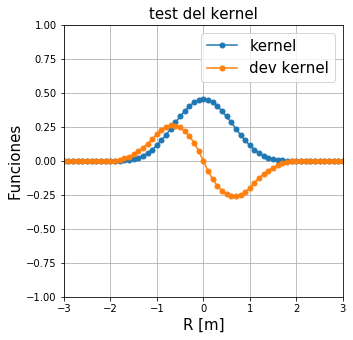

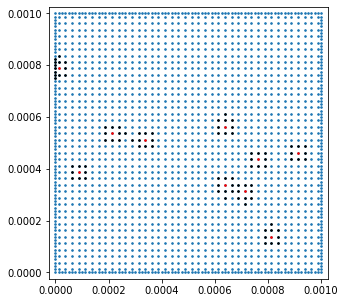

In [ ]:
def W(r,h):
    
    R = r/h
    alpha = 15.0/(7.0*pi*h*h)
    
    if (R >= 0.0) and (R < 1.0):
        return alpha*((2.0/3.0) - R*R + 0.5*R*R*R)
    elif (R >= 1.0) and (R < 2.0):
        return alpha*((1.0/6.0)*(2.0-R)*(2.0-R)*(2.0-R))
    else:
        return 0.0

def dW(r,dx,h):
     
    R = r/h
    alpha = 15.0/(7.0*pi*h*h)
    
    if (R >= 0.0) and (R < 1.0):
        return alpha*(-2.0 + 1.5*R)*dx/(h*h)
    elif (R >= 1.0) and (R < 2.0):
        return alpha*(-0.5*(2.0-R)*(2.0-R))*dx/(h*h*R)
    else:
        return 0.0
    
# test para el kernel

R = []
kernel = []
dkernel = []

l = list(range(-30,30+1,1))
for i in l:  
    R.append(i/10.0) 
    kernel.append(W(abs(R[i+30]),1.0))
    dkernel.append(dW(abs(R[i+30]),R[i+30]/sqrt(3),1.0))

fs = 15
figure(figsize=(5,5))
plot(R,kernel,ms=10,marker='.',label="kernel")
plot(R,dkernel,ms=10,marker='.',label="dev kernel")
grid()
xlabel("R [m]",fontsize=fs)
ylabel("Funciones",fontsize=fs)
xlim(-3.0,3.0)
ylim(-1.0,1.0)
legend(fontsize=fs)
title("test del kernel",fontsize=fs)
#show()

# busqueda de vecinos

def NNPS(i, kappa, NPart):
    
    nn = []
    d = []
    dx = []
    dy = []
    Wij = []
    dWijx = []
    dWijy = []
    
    for j in range(NPart):
        if j!=i:
            xij = x[i]-x[j]
            yij = y[i]-y[j]
            r = (sqrt( xij*xij + yij*yij ))
            hij = 0.5*(h[i]+h[j])
            if r<kappa*hij:
                nn.append(int(j))
                dx.append(xij)
                dy.append(yij)
                d.append(r)
                Wij.append(W(r,hij))
                dWijx.append(dW(r,xij,hij))
                dWijy.append(dW(r,yij,hij))
    
    return nn, d, Wij, dWijx, dWijy
        
# test para la busqueda de vecinos

import random

N = nx*ny + npVirt
kappa = 2.0

figure(figsize=(5,5))
scatter(x,y,s=10,marker='.')
for pt in range(10):
    i = random.randrange(nTotal)
    print("\nVecinos para particula",i)
    nn, r, Wij, dWijx, dWijy = NNPS(i,kappa, N)
    for vecinos in range(len(nn)):
        print(nn[vecinos],tipo[nn[vecinos]])
    scatter(x[i],y[i],s=10,marker='.',c='r')
    xnn = []
    ynn = []
    for j in range(len(nn)):
        xnn.append(x[nn[j]])
        ynn.append(y[nn[j]])
    scatter(xnn,ynn,s=10,marker='.',c='black')
    xlim(0.0-dx,Lx+dx)
    ylim(0.0-dy,Ly+dy)
#show()

# Inicializando SPH

## Densidad calculada como:

$\rho_i = \dfrac{\sum_{j=0}^{N} m_jW_{ij}}{\sum_{j=0}^{N} \left (\dfrac{m_j}{\rho_j} \right )W_{ij}}$

Para la evaluación del campo de densidad en la posición $\vec{r_i}$ es necesario considerar la densidad en esa posición, y se estima como:

$\rho_i = \dfrac{m_iW_{ii}}{\left (\dfrac{m_i}{\rho_i} \right )W_{ii}}$

In [ ]:
def densidad():
    # primeros vecinos

    kappa = 2.0
    NN = []
    r = []
    Wii = []
    Wij = []
    dWijx = []
    dWijy = []

    for i in range(nTotal):
        nn, d, wij, dwijx, dwijy = NNPS(i, kappa, nTotal+npVirt)
        NN.append(nn)
        r.append(d)
        Wij.append(wij)
        dWijx.append(dwijx)
        dWijy.append(dwijy)
        # autokernel
        Wii.append(W(0.0,h[i]))
    
    
    print("vecinos calculados")

    # densidad inicial

    for i in range(nTotal):
        den = m[i]*Wii[i]
        for k in range(len(NN[i])):
            j = NN[i][k]
            den = den + m[j]*Wij[i][k]
        rho[i] = den
    
    # normalizando la densidad
    for i in range(nTotal):
        norm = (m[i]/rho[i])*Wii[i]
        for k in range(len(NN[i])):
            j = NN[i][k]
            norm = norm + (m[j]/rho[j])*Wij[i][k]
        rho[i] = rho[i]/norm

    print("densidad calculada\n")
    
    return NN, rho, Wij, dWijx, dWijy

# Ecuación de Euler para el momento y la energía

 - La aceleración se calcula como:

$\dfrac{Dv_i^{\alpha}}{Dt}=-\sum_{j=0}^{N}m_j\left ( \dfrac{p_i}{\rho_i^2} + \dfrac{p_j}{\rho_j^2}\right )\dfrac{\partial W_{ij}}{\partial x_i^{\alpha}}$

Para calcular la presión usamos el modelo de compresibilidad artificial para imitar un flujo incompresible. En este la ecuaicón de estado es $p = c^2\rho$ con $c = 0.01\:m/s$ que corresponde a un número de Mach de $0.1$.

 - La energía se calcula como:
 
 $\dfrac{De_i}{Dt}=\dfrac{1}{2}\sum_{j=0}^{N}m_j\left ( \dfrac{p_i}{\rho_i^2} + \dfrac{p_j}{\rho_j^2}\right )v_{ij}^{\beta}\dfrac{\partial W_{ij}}{\partial x_i^{\beta}}$

In [ ]:
def navierStokes(NN,rho,dWijx,dWijy):
    # calculo presión

    def eos(rho, c):
        return c*c*rho


    for i in range(nTotal+npVirt):
        c[i] = 0.01
        p[i] = eos(rho[i],c[i])
  
    print("Presión calculada")

    # calculo aceleración y cambio temporal de energía

    dvxdt = []
    dvydt = []
    dedt = []

    for i in range(nTotal):
        ax = 0.0
        ay = 0.0
        de = 0.0
        for k in range(len(NN[i])):
            j = NN[i][k]
            pij = (p[i]/(rho[i]*rho[i])) + (p[j]/(rho[j]*rho[j])) 
            ax = ax - m[j]*pij*dWijx[i][k]
            ay = ay - m[j]*pij*dWijy[i][k]
            vdW = (vx[i]-vx[j])*dWijx[i][k] + (vy[i]-vy[j])*dWijy[i][k]
            de = de + 0.5*m[j]*pij*vdW
        dvxdt.append(ax)
        dvydt.append(ay)
        dedt.append(de)
        
    print("Aceleración calculada")
    print("Cambio temporal de energía calculado\n")
    return dvxdt, dvydt, dedt                

# Cálculo de la viscosidad artificial

\begin{equation}
\Pi_{ij} = \left\lbrace
\begin{array}{cc}
\dfrac{-\alpha_{\Pi}\overline{c}_{ij}\phi_{ij}+\beta_{\Pi}\phi_{ij}^2}{\overline{\rho}_{ij}} & \vec{v}_{ij} \bullet \vec{x}_{ij} < 0\\
0 & \vec{v}_{ij} \bullet \vec{x}_{ij} \geq 0
\end{array}
\right.
\end{equation}

con:
\begin{equation}
\phi_{ij} = \dfrac{ h_{ij} \vec{v}_{ij} \bullet \vec{x}_{ij} }{ |\vec{x}_{ij}|^2 + \varphi^2}
\end{equation}

\begin{equation}
\overline{c}_{ij} = \dfrac{1}{2}\left ( c_i+c_j \right ) 
\end{equation}

\begin{equation}
\overline{\rho}_{ij} = \dfrac{1}{2}\left ( \rho_i+\rho_j \right ) 
\end{equation}

\begin{equation}
h_{ij} = \dfrac{1}{2}\left ( h_i+h_j \right ) 
\end{equation}

\begin{equation}
\vec{v}_{ij} = \vec{v}_i-\vec{v}_j
\end{equation}

\begin{equation}
\vec{x}_{ij} = \vec{x}_i-\vec{x}_j
\end{equation}

In [ ]:
def viscosidad(NN, rho, dWijx, dWijy, dvxdt, dvydt, dedt):
    # Viscosidad artificial

    alphapi = 1.0
    betapi = 1.0
    eps = dx
    eps2 = 0.01*eps*eps

    for i in range(nTotal):
        for k in range(len(NN[i])):
            j = NN[i][k]
            rijx = x[i] - x[j]
            rijy = y[i] - y[j]
            vijx = vx[i] - vx[j]
            vijy = vy[i] - vy[j]
            vijrij = vijx*rijx + vijy*rijy
            if vijrij < 0.0:
                hij = 0.5*(h[i]+h[j])
                phiij = (hij*vijrij)/( rijx*rijx + rijy*rijy + eps2)
                cij = 0.5*(c[i]+c[j])
                rhoij = 0.5*(rho[i]+rho[j])
                Piij = ( -alphapi*cij*phiij + betapi*phiij*phiij )/( rhoij )
            else:
                Piij = 0.0
            # adicionando viscocidad a las ecuaciones de movimiento
            dvxdt[i] = dvxdt[i] + (-m[j]*Piij*dWijx[i][k])
            dvydt[i] = dvydt[i] + (-m[j]*Piij*dWijy[i][k])
            vdW = (vx[i]-vx[j])*dWijx[i][k] + (vy[i]-vy[j])*dWijy[i][k]
            dedt[i] = dedt[i] + 0.5*m[j]*Piij*vdW

    print("Viscocidad calculada")
    return 1    

# Interacción con fronteras

Las partículas virtuales de tipo I usadas en esta simulación generan una fuerza de repulsión dada por:

\begin{equation}
PB_{ij} = \left\lbrace
\begin{array}{cc}
D \left[\left(\dfrac{r_0}{r_{ij}}\right)^{n_1}-\left(\dfrac{r_0}{r_{ij}}\right)^{n_2}\right]\dfrac{\vec{x}_{ij}}{r_{ij}^2} & \left(\dfrac{r_0}{r_{ij}}\right) \leq 1\\
0 & \left(\dfrac{r_0}{r_{ij}}\right) > 1
\end{array}
\right.
\end{equation}

Con $r_0=dx/2=1.25\times 10^{-5}$, $n_1=12$, $n_2=4$ y $D=0.01$.

In [ ]:
def frontera(NN, dvxdt, dvydt):
    
    r0 = dx/2.0
    n1 = 12
    n2 = 4
    D = 0.01
    
    for i in range(nTotal):
        for k in range(len(NN[i])):
            j = NN[i][k]
            if tipo[j]==-1:
                xij = x[i]-x[j]
                yij = y[i]-y[j]
                rij = sqrt( xij*xij + yij*yij )
                if rij<r0:
                    PBxij = D*( (r0/rij)**n1 - (r0/rij)**n2 )*(xij/(rij*rij))
                    PByij = D*( (r0/rij)**n1 - (r0/rij)**n2 )*(yij/(rij*rij))
                else:
                    PBxij = 0.0
                    PByij = 0.0
                dvxdt[i] = dvxdt[i] + PBxij
                dvydt[i] = dvydt[i] + PByij
    
    print("Interacción con fronteras")
    return 1

# Velocidad promedio

Este modelo de XSPH cambia la velocidad de las partículas teniendo en cuenta el promedio de la velocidad de las partículas vecinas. Esto favorece el comportamiento homogéneo del fluido y evita qu elas partículas penetren las paredes.

La velocidad de las partículas se modifica como:

\begin{equation}
\dfrac{d\vec{x}_i}{dt} = \vec{v}_i - \epsilon\sum_{j=0}^{N}\frac{m_j}{\overline{\rho}_{ij}}\vec{v}_{ij}W_{ij},
\end{equation}

con $\epsilon=0.3$

In [ ]:
def velPromedio(NN, Wij):
    
    epsilon = 0.3
    
    for i in range(nTotal):
        vMeanx = 0.0
        vMeany = 0.0
        for k in range(len(NN[i])):
            j = NN[i][k]
            vijx = vx[i] - vx[j]
            vijy = vy[i] - vy[j]
            rhoij = 0.5*(rho[i]+rho[j])
            vMeanx = vMeanx + (m[j]/rhoij)*vijx*Wij[i][k]
            vMeany = vMeany + (m[j]/rhoij)*vijy*Wij[i][k]
        vx[i] = vx[i] - epsilon*vMeanx
        vy[i] = vy[i] - epsilon*vMeany
        
    return 1

# Evolución temporal del fluido

Se realizará integrando las ecuaciones de movimiento con un integrador *leap-frog* con $\Delta t$ fijo. El esquema de integración es el siguiente:

En cada $\Delta t$ el sistema evoluciona como:

- Paso 1: $\vec{r}_{t+1/2} = \vec{r}_{t} + \dfrac{\Delta t}{2}\vec{v}_{t}$ (avanza la posición $\dfrac{\Delta t}{2}$)
- Paso 2: $\vec{v}_{t+1} = \vec{v}_{t} + \Delta t \vec{a}_{t}$ (avanza la velocidad $\Delta t$)
- Paso 3: $\vec{r}_{t} = \vec{r}_{t+1/2} + \dfrac{\Delta t}{2}\vec{v}_{t+1}$ (avanza la posición $\dfrac{\Delta t}{2}$)

Este mismo esquema será usado para integrar la ecuación de energía.

El tiempo total de integración será de $4000\Delta t$ con $\Delta t=5\times 10^{-5}$.

In [ ]:
def integracion(dt, dvxdt, dvydt, dedt):
    
    for i in range(nTotal): 
        
        # paso 1
        x[i] = x[i] + 0.5*dt*vx[i]
        y[i] = y[i] + 0.5*dt*vy[i]
        
        # paso 2
        vx[i] = vx[i] + dt*dvxdt[i]
        vy[i] = vy[i] + dt*dvydt[i]
        
        # paso 3
        x[i] = x[i] + 0.5*dt*vx[i]
        y[i] = y[i] + 0.5*dt*vy[i]
        u[i] = u[i] + dt*dedt[i]
        
        #if i%100==0:
            #print('%.8d %.8f %.8f %.8f %.8f %.8f %.8f %.8f %.8f'%(i, dt, x[i], y[i], vx[i], vy[i], dvxdt[i], dvydt[i], dedt[i]))
        #print(i, dt, x[i], y[i], vx[i], vy[i], dvxdt[i], dvydt[i], dedt[i])
        
    return 1

# Imprime estado

Se imprime un archivo con los datos del estado físico de las partículas de la simulación. cada fila representa la información de una partícula y el formato por columnas es el siguiente:

- Identificador de la partícula
- Coordenada x
- Coordenada y
- Velocidad en x
- Velocidad en y
- densidad
- presión
- energía interna

In [ ]:
def imprime(counter):
    
    # abre archivo
    estado = open("./estado_%.4d.dat"%(counter),"w")
    
    # escribe datos en archivo
    for i in range(nTotal+npVirt):
        estado.write("%.3d %.8f %.8f %.8f %.8f %.8f %.8f %.8f\n"%(i,x[i],y[i],vx[i],vy[i],rho[i],p[i],u[i]))
    
    # cierra archivo
    estado.close()
    
    return 1

In [ ]:
t = 0.0
dt = 5e-5
tTotal = 4000*dt
counter = 0

print("Inicia simulación\n\n")

# imprime estado inicial
imprime(counter)

# ciclo temporal

while t<=tTotal:
    
    print("\nTiempo de simulación t = %.8f"%t,"s - paso =",counter,"\n")
    # cálculo de densidad (incluye la búsqueda de vecinos)
    NN, rho, Wij, dWijx, dWijy = densidad()
    # ecuaciones de Navier-Stokes
    dvxdt, dvydt, dedt = navierStokes(NN, rho, dWijx, dWijy)
    # calculo de viscosidad artificial
    viscosidad(NN, rho, dWijx, dWijy, dvxdt, dvydt, dedt)
    # calculo de interacion con las fronteras
    frontera(NN, dvxdt, dvydt)
    # calculo de la velocidad promedio
    velPromedio(NN, Wij)
    # integración
    integracion(dt, dvxdt, dvydt, dedt)
    
    counter += 1
    t += dt
    # imprime estado 
    imprime(counter)
    
else:
    print("\nSimulación terminada")